Black Scholes Option Pricing Model
### Real World Implementation — iShares Silver Trust (SLV)

This notebook prices a real SLV call option contract (SLV260515C00074000) 
using the Black-Scholes-Merton model with live market data.

**Methodology:**
- Historical volatility calculated from 1 year of live price data
- BSM formula implemented from scratch
- GBM simulation to model stock price paths
- Monte Carlo simulation (100,000 iterations) to validate trading edge


In [1]:
# Calculating option price using Black scholes model and plotting it to come to a conclusion

In [2]:
# option contract: SLV260515C00074000

In [3]:
# Underlying asset: iShares Silver Trust (SLV)

In [4]:
import numpy as np

In [5]:
from scipy.stats import norm

In [6]:
# σ( volatility calculation)


In [7]:
import pandas as pd

In [8]:
import pandas_datareader as pdr

In [9]:
import datetime as dt

In [10]:
import yfinance as yf

## Step 1 — Volatility Calculation
Historical volatility is calculated from 1 year of SLV closing prices.
Log returns are used as BSM assumes normally distributed returns.
Daily volatility is annualised by multiplying by √252.


In [11]:
enddate= dt.datetime.now()

In [12]:
startdate= enddate - dt.timedelta(days = 365*1)

In [13]:
stocks= ['SLV']

In [14]:
df= yf.download(stocks, startdate, enddate, auto_adjust= True)

[*********************100%***********************]  1 of 1 completed


In [15]:
Adj_closing_prices= df['Close']

In [16]:
log_returns= np.log(Adj_closing_prices/Adj_closing_prices.shift(1))

In [17]:
daily_vol= log_returns.std().iloc[0]

In [18]:
annual_vol= daily_vol*np.sqrt(252)

In [19]:
print(annual_vol)

0.6210835663277358


## Step 2 — Black-Scholes Pricing

In [20]:
# defining variables for BS model
S= 72.54 #underlying price
K= 74.00 #Strike price
T= 0.027777777778 #Time to expiration #7 days to expire
r= 0.0363 #UST 1 Month yield
vol= 0.6080755418348802 #σ Volatility of the underlying (historical)



In [21]:
def black_scholes_call(S, K, T, r, vol):
    d1 = (np.log(S/K) + (r + 0.5*vol**2)*T)/(vol*np.sqrt(T))
    d2= d1 - (vol*np.sqrt(T))
    C= S*norm.cdf(d1) -((K*np.exp(-r*T))*norm.cdf(d2))
    return C 
                         

In [22]:
call_price= black_scholes_call(S, K, T, r, vol)
print(call_price)

2.3182792443950824


In [23]:
import matplotlib.pyplot as plt


## Step 3 — GBM Price Path Simulation
Stock price is simulated using Geometric Brownian Motion over 7 steps,
matching the actual trading days to expiry of the option contract.
Each step draws a random shock from a normal distribution — 
consistent with BSM's core assumption.


In [24]:
S0= 72.54
mu= 0.0363
σ= 0.6080755418348802
T= 0.027777777778
dt= 1/252
N= int(T/dt)

In [25]:
print(N)

7


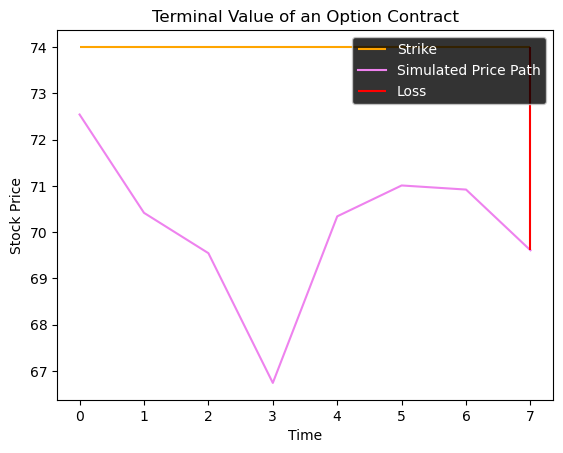

Black-Scholes price 2.3182792443950824
P/L: -2.3182792443950824


In [26]:
prices= [S0]
for i in range(N):
    Z= np.random.normal()
    St= prices[-1]*np.exp((mu- 0.5*σ**2)*dt +𝛔*Z*np.sqrt(dt))
    prices.append(St)
    
plt.title("Terminal Value of an Option Contract")
plt.hlines(74, 0, 7, label= 'Strike', color='orange')
plt.plot(prices, label='Simulated Price Path', color= 'violet')
if  max(prices[-1] - K, 0) ==0:
    plt.vlines(7, prices[-1], 74, color= 'red', label='Loss')
else:
    plt.vlines(7, prices[-1], 74, color='green', label='Profit')

plt.style.use('dark_background')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

print("Black-Scholes price", black_scholes_call(S, K, T, r, vol))
print("P/L:",  max(prices[-1] - K, 0)- black_scholes_call(S, K, T, r, vol))

    

In [27]:
print("Call price:", black_scholes_call(S, K, T, r, vol))
print("Market Maker Quote", "1.500 @ 1.5500")
print("Trade Edge", black_scholes_call(S, K, T, r, vol) - 1.5500)


Call price: 2.3182792443950824
Market Maker Quote 1.500 @ 1.5500
Trade Edge 0.7682792443950823


## Step 4 — Monte Carlo Simulation
100,000 simulations are run to calculate the expected P/L.
A positive mean P/L confirms the trading edge identified by BSM.


In [28]:
premium = 1.5500*100
pls= []
for i in range(100000):
    prices= [S0]
    for j in range(7):
         Z= np.random.normal()
         St= prices[-1]*np.exp((mu- 0.5*σ**2)*dt +𝛔*Z*np.sqrt(dt))
         prices.append(St)
   
    pl= max(prices[-1] - 74,0)*100 - premium
    pls.append(pl)
    
print(np.mean(pls))
    

78.54709319518322


## Calculation of greeks for the option contract
The Greeks measure the sensitivity of the option 
price to changes in market parameters.

- **Delta** — price change per $1 move in underlying
- **Gamma** — rate of change of delta
- **Theta** — time decay per day
- **Vega**  — sensitivity to 1% change in volatility
- **Rho**   — sensitivity to 1% change in interest rate


In [29]:
# Import required libraries
import numpy as np
from scipy.stats import norm

# Greeks
def delta_call(S, K, T, r, vol):
    d1 = (np.log(S/K) + (r + 0.5*vol**2)*T)/(vol*np.sqrt(T))
    return norm.cdf(d1)
    
def gamma_call(S, K, T, r, vol):
    d1 = (np.log(S/K) + (r + 0.5*vol**2)*T)/(vol*np.sqrt(T))
    return norm.pdf(d1)/(S*vol*np.sqrt(T))
    
def theta_call(S, K, T, r, vol):
    d1= (np.log(S/K) + (r + 0.5*vol**2)*T)/(vol*np.sqrt(T))
    d2 = d1 - (vol*np.sqrt(T))
    annual_theta= (-(S*norm.pdf(d1)*vol)/(2*np.sqrt(T))) - (r*K*np.exp(-r*T)*norm.cdf(d2))
    return annual_theta/365
    
def vega_call(S, K, T, r, vol):
    d1= (np.log(S/K) + (r + 0.5*vol**2)*T)/(vol*np.sqrt(T))
    return S*norm.pdf(d1)*np.sqrt(T)*0.01

def rho_call(S, K, T, r, vol):
   d1=  (np.log(S/K) + (r + 0.5*vol**2)*T)/(vol*np.sqrt(T))
   d2= d1 - (vol*np.sqrt(T))
   return K*T*np.exp(-r*T)*norm.cdf(d2)*0.01



# Calculate and print the Greeks
print("Delta:", round(delta_call(S, K, T, r, vol), 4))
print("Gamma:", round(gamma_call(S, K, T, r, vol), 4))
print("Theta:", round(theta_call(S, K, T, r, vol), 4))
print("Vega:", round(vega_call(S, K, T, r, vol), 4))
print("Rho:", round(rho_call(S, K, T, r, vol), 4))

Delta: 0.4459
Gamma: 0.0538
Theta: -0.1463
Vega: 0.0478
Rho: 0.0083


## Conclusions

The Black-Scholes model prices the SLV call option 
(SLV260515C00074000) at USD 2.3 against a market price of USD 1.55, implying a theoretical trading edge 
of USD 0.77.

This edge was validated through 100,000 Monte Carlo 
simulations under GBM dynamics, producing a mean 
expected P/L of USD 78.67 per 100 contracts.

This suggests the option is underpriced relative to 
BSM fair value — presenting a potential long call 
opportunity at the time of analysis (May 2026).

## Model Assumptions & Limitations

| Assumption | Limitation |
|---|---|
| Constant volatility | Real vol is stochastic — BSM ignores the volatility smile |
| Log-normally distributed returns | Real returns exhibit fat tails and negative skew |
| No dividends | SLV pays no dividends — assumption holds here |
| European exercise only | Cannot account for early exercise |
| Constant risk-free rate | Yield curve shifts are ignored |
| Continuous trading | Ignores bid-ask spreads and transaction costs |

**Extensions:** These limitations motivate more advanced 
models such as Heston (stochastic volatility), 
SABR, and Monte Carlo with jump diffusion.